# CrewAI Image Generator (Notebook)

Este notebook mueve la logica de src/lab3_crewai_image_generator/crew.py a formato ejecutable por celdas.

Flujo:
1. writer crea descripcion tecnica
2. reviewer mejora y aprueba el texto
3. image_creator usa la tool generate_image

In [18]:
!uv pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
import tempfile
from pathlib import Path

from dotenv import load_dotenv
from crewai import Agent, Crew, Process, Task
from crewai.tools import tool
from google import genai
from google.genai import types

load_dotenv(override=True)
os.environ.setdefault("OPENAI_AGENTS_DISABLE_TRACING", "1")

for key in ("OPENAI_API_KEY", "GOOGLE_API_KEY"):
    val = os.getenv(key)
    if val:
        print(f"{key}: {val[:8]}...{val[-4:]}")
    else:
        print(f"{key} not found.")

import nest_asyncio
nest_asyncio.apply()


OPENAI_API_KEY: sk-proj-...66gA
GOOGLE_API_KEY: AQ.Ab8RN...hGsw


In [20]:
gemini_client = genai.Client()
GEMINI_IMAGE_MODEL = "gemini-3.1-flash-image"

IMAGE_PROMPT_TEMPLATE = """
16:9 landscape hand-drawn whiteboard illustration on off-white paper with faint blueprint grid lines.
COMPOSITION: All elements centered with 15% margin on all sides.

Subject: {approved_text}

VISUAL REQUIREMENTS:
- Each component represented by a DISTINCTIVE ICON (gears, brains, clouds, envelopes, shields, etc.) inside or above its labeled box
- Boxes connected by sketchy arrows with small annotations on the arrows describing the data flow
- Small decorative doodles: stars, lightbulbs, checkmarks, dotted trails, tiny sparkles. DON'T overdo it; keep it subtle and balanced.
- Color-coded watercolor fills: each box a different soft color (blue, green, orange, coral, purple)
- Short Spanish labels in handwritten script inside each box

Style: hand-drawn pen-and-ink sketch with loose cross-hatching and watercolor accents.
Analog, warm, textured feel - like a creative brainstorming whiteboard. No digital vectors. No title.
"""

IMAGE_GEN_CONFIG = types.GenerateContentConfig(
    response_modalities=["IMAGE"],
    image_config=types.ImageConfig(aspect_ratio="16:9"),
)

last_image_path = None

@tool
def generate_image(approved_text: str) -> str:
    """Genera una imagen estilo whiteboard a partir de texto aprobado."""
    global last_image_path

    image_prompt = IMAGE_PROMPT_TEMPLATE.format(approved_text=approved_text)

    response = gemini_client.models.generate_content(
        model=GEMINI_IMAGE_MODEL,
        contents=image_prompt,
        config=IMAGE_GEN_CONFIG,
    )

    image_bytes = None
    for part in response.candidates[0].content.parts:
        if part.inline_data and part.inline_data.data:
            image_bytes = part.inline_data.data
            break

    if not image_bytes:
        return "ERROR: No se genero ninguna imagen."

    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    tmp.write(image_bytes)
    tmp.close()
    last_image_path = tmp.name
    return f"Imagen generada correctamente en: {tmp.name}"

print("Tool generate_image lista.")

Tool generate_image lista.


In [21]:
agents_config = {
    "writer": {
        "role": "Escritor Tecnico",
        "goal": "Crear descripciones tecnicas detalladas y visuales de conceptos complejos",
        "backstory": (
            "Eres un comunicador tecnico experto con 10 anos de experiencia creando documentacion visual. "
            "Tu especialidad es convertir conceptos abstractos en descripciones que cualquiera pueda visualizar como un diagrama. "
            "Incluyes siempre los componentes principales, como interactuan, el flujo de operaciones, y detalles visuales concretos."
        ),
        "llm": "gpt-4.1-nano",
        "verbose": True,
    },
    "reviewer": {
        "role": "Revisor Senior",
        "goal": "Asegurar que las descripciones son completas, claras y tienen suficiente detalle visual",
        "backstory": (
            "Eres un lider tecnico senior con ojo para el detalle. Tu trabajo es revisar descripciones y enriquecerlas. "
            "Si algo falta, lo anades. Si algo es vago, lo haces concreto. "
            "Siempre devuelves al menos 4-6 frases de descripcion rica."
        ),
        "llm": "gpt-4.1-mini",
        "verbose": True,
    },
    "image_creator": {
        "role": "Creador de Imagenes",
        "goal": "Generar imagenes whiteboard profesionales a partir de texto aprobado usando generate_image",
        "backstory": (
            "Eres un artista visual especializado en diagramas estilo whiteboard. "
            "Tomas texto tecnico aprobado y usas tu herramienta generate_image para crear la imagen. "
            "Siempre pasas el texto completo como argumento approved_text."
        ),
        "llm": "gpt-4.1-mini",
        "verbose": True,
    },
}

tasks_config = {
    "write_task": {
        "description": (
            "Escribe una descripcion tecnica detallada sobre: {topic}\n\n"
            "Incluye componentes principales, interacciones, flujo de operaciones y detalles visuales."
        ),
        "expected_output": "Descripcion tecnica de 3-5 frases con componentes, flujos y detalles visuales."
    },
    "review_task": {
        "description": (
            "Revisa la descripcion tecnica anterior y enriquecela.\n"
            "Asegura componentes clave, relaciones, secuencia y detalle visual suficiente."
        ),
        "expected_output": "Texto mejorado y enriquecido con todos los detalles necesarios para visualizacion."
    },
    "image_task": {
        "description": (
            "Toma el texto aprobado y usa generate_image para crear una imagen whiteboard.\n"
            "Pasa el texto completo como argumento approved_text."
        ),
        "expected_output": "Ruta al archivo de imagen generado."
    },
}

writer = Agent(config=agents_config["writer"])
reviewer = Agent(config=agents_config["reviewer"])
image_creator = Agent(config=agents_config["image_creator"], tools=[generate_image])

write_task = Task(config=tasks_config["write_task"], agent=writer)
review_task = Task(config=tasks_config["review_task"], agent=reviewer, context=[write_task])
image_task = Task(config=tasks_config["image_task"], agent=image_creator, context=[review_task])

image_crew = Crew(
    agents=[writer, reviewer, image_creator],
    tasks=[write_task, review_task, image_task],
    process=Process.sequential,
    verbose=True,
)

print("Crew creada.")

Crew creada.


In [22]:
topic = "How multi-agent systems coordinate tasks using handoffs"
result = await image_crew.kickoff_async(inputs={"topic": topic})
print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: c5751968-d88b-47d4-b4ba-517beb7905a4                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Escribe una descripcion tecnica detallada sobre: How multi-agent systems coordinate tasks using          │
│  handoffs                                                                                                       │
│                                                                                                                 │
│  Incluye componentes principales, interacciones, flujo de operaciones y detalles visuales.                      │
│  ID: 2807fe9c-acbc-4a43-9045-ea851f025061                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Escritor Tecnico                                                                                        │
│                                                                                                                 │
│  Task: Escribe una descripcion tecnica detallada sobre: How multi-agent systems coordinate tasks using          │
│  handoffs                                                                                                       │
│                                                                                                                 │
│  Incluye componentes principales, interacciones, flujo de operaciones y detalles visuales.                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Escritor Tecnico                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Un sistema multi-agente que coordina tareas mediante handoffs consta de componentes principales: agentes       │
│  individuales, un servidor de coordinación y una interfaz de comunicación. Cada agente realiza tareas           │
│  específicas y se comunica con otros agentes mediante mensajes hacia y desde el servidor, que actúa como        │
│  intermediario. El flujo de operaciones inicia con un agente que, ante una tarea incompleta, solicita           │
│  asistencia o pasa la responsabilidad mediante un handoff, enviando un mensaje de transferencia al servidor,    │
│  que redirige la tarea a un agente adecuado. Visualmente, esto se representa como una serie de nodos (agentes)  │
│  conectados por flechas bidireccionales (mensajes), con el servidor en el centro gestionando las                │
│  transferencias, y las transiciones de responsabilidad se muestran mediante flechas que indican el flujo de la  │
│  tarea desde un agente a otro a través del sistema.                                                             │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Creador de Imagenes                                                                                     │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  /var/folders/85/lb6y36y56fj3hgs9zb0lhqgc0000gq/T/tmprqrp31b8.png                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Toma el texto aprobado y usa generate_image para crear una imagen whiteboard.                            │
│  Pasa el texto completo como argumento approved_text.                                                           │
│  Agent: Creador de Imagenes                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: c5751968-d88b-47d4-b4ba-517beb7905a4                                                                       │
│  Final Output: /var/folders/85/lb6y36y56fj3hgs9zb0lhqgc0000gq/T/tmprqrp31b8.png                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

/var/folders/85/lb6y36y56fj3hgs9zb0lhqgc0000gq/T/tmprqrp31b8.png


╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Imagen generada en: /var/folders/85/lb6y36y56fj3hgs9zb0lhqgc0000gq/T/tmprqrp31b8.png


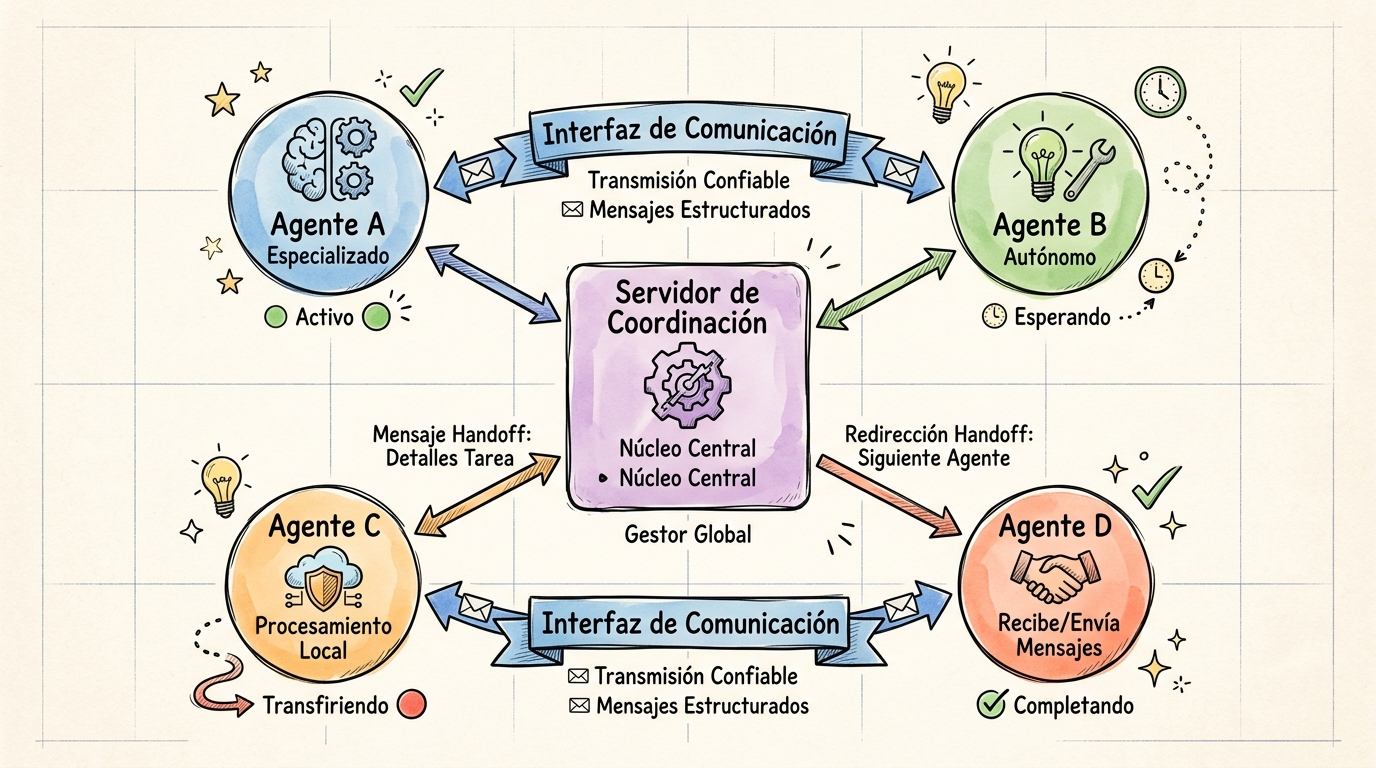

In [23]:
from IPython.display import Image, display

if last_image_path and Path(last_image_path).exists():
    print(f"Imagen generada en: {last_image_path}")
    display(Image(filename=last_image_path))
else:
    print("No hay imagen generada todavia. Ejecuta la celda de kickoff.")